In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
train = pd.read_csv(r'C:\Users\abbas\Downloads\archive\train.csv')
test= pd.read_csv(r'C:\Users\abbas\Downloads\archive\test.csv')

In [5]:
train.info()
train.describe(include='all')
train.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


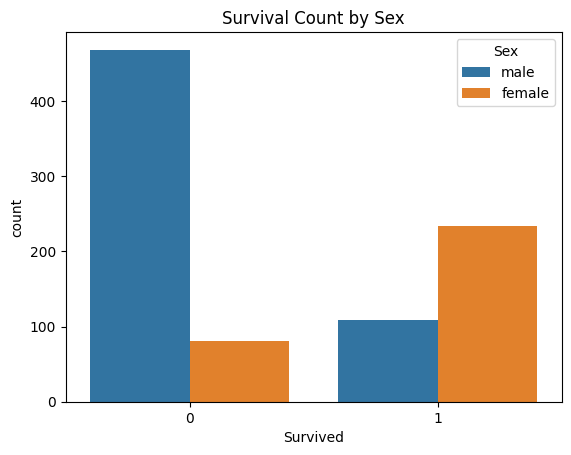

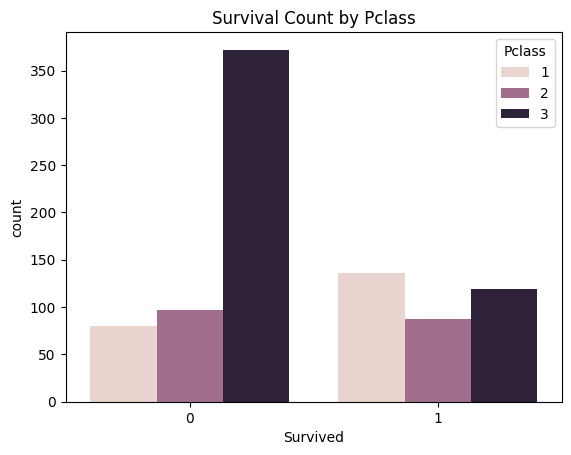

In [6]:
# Visualizing Survival by Sex
sns.countplot(x='Survived', hue='Sex', data=train)
plt.title('Survival Count by Sex')
plt.show()

# Visualizing Survival by Passenger Class
sns.countplot(x='Survived', hue='Pclass', data=train)
plt.title('Survival Count by Pclass')
plt.show()

In [ ]:
# Clean missing values
train_clean = train.copy()
train_clean['Age'] = train_clean['Age'].fillna(train_clean['Age'].median())
train_clean['Embarked'] = train_clean['Embarked'].fillna(train_clean['Embarked'].mode()[0])
train_clean['Cabin'] = train_clean['Cabin'].fillna('Unknown')

print('Missing values after cleaning:')
print(train_clean.isna().sum())

# Histogram of Age
plt.figure(figsize=(8,4))
sns.histplot(train_clean['Age'], bins=20, kde=True, color='steelblue')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

# Outlier detection on Fare
plt.figure(figsize=(8,4))
sns.boxplot(x=train_clean['Fare'], color='lightgreen')
plt.title('Fare Boxplot (Outlier Detection)')
plt.xlabel('Fare')
plt.show()

# Bar chart: survival by passenger class
plt.figure(figsize=(8,4))
sns.countplot(x='Pclass', hue='Survived', data=train_clean, palette='muted')
plt.title('Survival by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Count')
plt.legend(title='Survived', labels=['No', 'Yes'])
plt.show()

# Correlation heatmap of numeric features
numeric_cols = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
plt.figure(figsize=(8,6))
sns.heatmap(train_clean[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Correlation Heatmap of Numeric Features')
plt.show()

# Data cleaning and survival analysis narrative

I used median imputation for Age because it is a numeric column with a moderate amount of missingness and the median is robust to skewed ages. For Embarked, I filled missing entries with the mode since almost all records have a valid port and the most common port is a reasonable default. Cabin was filled with 'Unknown' because the missingness is too high to safely impute meaningful values.

The Fare boxplot shows extreme high values that are likely outliers, so I will keep them for now and treat them as real expensive tickets rather than measurement errors. The most important feature for survival appears to be `Pclass`, because first-class passengers clearly survived at a higher rate and `Pclass` also has a strong negative correlation with Survived in the heatmap.